# MLP — tijdsvoorspelling en medewerkersranking

Dit notebook bouwt een MLP (Multi-Layer Perceptron) als deep learning baseline voor het Rister project. Het model bestaat uit een paar Linear + ReLU + Dropout lagen met entity embeddings voor categorische features.

Het doel is simpel: ik wil weten of een standaard DL-aanpak de LightGBM baseline kan evenaren of verbeteren. De architectuur houd ik zo eenvoudig mogelijk — geen fancy tricks, gewoon een MLP.

**Dataset:** 28.693 rijen, 41 kolommen  
**Features:** 11 categorisch + 22 numeriek = 33 features (3 kolommen niet aanwezig in dataset)  
**Model:** 394.695 trainbare parameters

**KPIs uit het projectplan:**
- Regressie (tijdsvoorspelling): MAE ≤ 0,5 uur
- Ranking (medewerkersgeschiktheid): NDCG@3 ≥ 0,80

**LightGBM referentieresultaten:**
- MAE: 1,2490 uur | RMSE: 1,9767 | R²: 0,6392
- NDCG@3: 0,9541 | NDCG@5: 0,9517

**MLP resultaten (dit notebook):**
- MAE: 1,3634 uur | RMSE: 2,1182 | R²: 0,5857
- NDCG@3: 0,6285 | NDCG@5: 0,6322
- Top-3 hit rate: 18,4%

Het MLP scoort op alle metrics slechter dan LightGBM. Voor tabular data met veel categorische features wint de gradient boosting aanpak hier duidelijk.

**Twee modellen:**
- **Model A** — regressie: voorspelt de werktijd in uren (`REAL_WORKED_TIME`)
- **Model B** — ranking: scoort de geschiktheid van een medewerker voor een taak (`suitability_score`)

## Stap 1 — Imports

In [8]:
import copy
import json
import os

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import onnxruntime as ort
import optuna
import pandas as pd
import torch
import torch.nn as nn
from mlflow.tracking import MlflowClient
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset

# Reproduceerbaar
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


## Stap 2 — MLflow configuratie

In [9]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5002"
MLFLOW_EXPERIMENT = "rister-mlp-v1"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow experiment: {MLFLOW_EXPERIMENT}")

MLflow experiment: rister-mlp-v1


## Stap 3 — Data laden

In [10]:
df = pd.read_csv("dataframe_gecombineerd.csv")

# Kolom mismatch fix (bekend probleem in de dataset)
if "aarURENVERANTW_MEDID" in df.columns:
    df.rename(columns={"aarURENVERANTW_MEDID": "URENVERANTW_MEDID"}, inplace=True)

print(f"Dataset: {df.shape[0]} rijen, {df.shape[1]} kolommen")
df.head(3)

Dataset: 28693 rijen, 41 kolommen


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/2614432725.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataframe_gecombineerd.csv")


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
1,11,1043,NaN,4144.0,Aanvulzand (af Rook etc.),NaN,2355AH,52.168026,4.580257,2015-01-19,...,1.0,15_poel,3.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
2,30,1275,NaN,4312.0,Schelpen (afgehaald GP),NaN,2481KA,52.166547,4.603481,2015-01-23,...,1.0,15_poel,2.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000


## Stap 4 — Features & targets

**Let op:** 3 kolommen uit de originele feature lijst zitten niet in de dataset (`med_klanttijd_ratio`, `med_bewerking_hoeveelheid`, `med_kl_bew_snelheid`). Die worden automatisch overgeslagen. Het model traint op 11 categorische + 22 numerieke features.

In [11]:
CATEGORICAL = [
    "URENVERANTW_MEDID",
    "BEWERKING_ID",
    "DIENST_ART_ID",
    "RELATIE_ID",
    "REL_POSTCODE",
    "DIENST_ART_OMS",
    "MACH_OMS",
    "con",
    "bron",
    "EquipmentGroupTypes",
    "planninggroupsname",
]

NUMERICAL = [
    "lat",
    "lon",
    "dag_sin",
    "dag_cos",
    "maand_sin",
    "maand_cos",
    "week_sin",
    "week_cos",
    "med_std_tijd",
    "med_aantal_opdrachten",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "taak_gem",
    "med_klant_bezoeken",
    "med_klant_ratio",
    "med_klant_snelheid",
    "med_bewerking_snelheid",
    "med_klanttijd_ratio",
    "med_bewerking_hoeveelheid",
    "med_kl_bew_snelheid",
    "hoeveelheid_volume",
    "hoeveelheid_gewicht",
    "hoeveelheid_stuks",
    "hoeveelheid_aanwezig",
    "hoeveelheid_baal",
]

TARGET_TIME = "REAL_WORKED_TIME"
TARGET_RANK = "suitability_score"
GROUP_COLS = ["con", "BEWERKING_ID"]

# Filter op kolommen die werkelijk in de dataset zitten
CATEGORICAL = [c for c in CATEGORICAL if c in df.columns]
NUMERICAL = [c for c in NUMERICAL if c in df.columns]
FEATURES = CATEGORICAL + NUMERICAL

missing = [
    c
    for c in [
        "URENVERANTW_MEDID",
        "BEWERKING_ID",
        "DIENST_ART_ID",
        "RELATIE_ID",
        "REL_POSTCODE",
        "DIENST_ART_OMS",
        "MACH_OMS",
        "con",
        "bron",
        "EquipmentGroupTypes",
        "planninggroupsname",
        "lat",
        "lon",
        "dag_sin",
        "dag_cos",
        "maand_sin",
        "maand_cos",
        "week_sin",
        "week_cos",
        "med_std_tijd",
        "med_aantal_opdrachten",
        "med_ervaring_bewerking",
        "med_gem_tijd",
        "taak_gem",
        "med_klant_bezoeken",
        "med_klant_ratio",
        "med_klant_snelheid",
        "med_bewerking_snelheid",
        "med_klanttijd_ratio",
        "med_bewerking_hoeveelheid",
        "med_kl_bew_snelheid",
        "hoeveelheid_volume",
        "hoeveelheid_gewicht",
        "hoeveelheid_stuks",
        "hoeveelheid_aanwezig",
        "hoeveelheid_baal",
    ]
    if c not in df.columns
]
if missing:
    print(f"Niet gevonden in dataset (overgeslagen): {missing}")

# Embedding dimensies per categorische feature
EMBED_DIMS = {col: min(50, max(2, (df[col].nunique() + 1) // 2)) for col in CATEGORICAL}

print("Categorisch:", len(CATEGORICAL), "features")
print("Numeriek:", len(NUMERICAL), "features")

Niet gevonden in dataset (overgeslagen): ['med_klanttijd_ratio', 'med_bewerking_hoeveelheid', 'med_kl_bew_snelheid']
Categorisch: 11 features
Numeriek: 22 features


## Stap 5 — Data voorbereiding

MLP heeft geen native categorische support zoals LightGBM. Ik gebruik entity embeddings: elke categorische waarde krijgt een integer index, die vervolgens door een `nn.Embedding` laag loopt. Dit werkt goed voor tabular data met hoge kardinaliteit.

In [12]:
# Label encode alle categorische features
label_encoders = {}
for col in CATEGORICAL:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].fillna("unknown").astype(str)).tolist()
    label_encoders[col] = le

CAT_ENC_COLS = [c + "_enc" for c in CATEGORICAL]
cat_cardinalities = [int(df[c + "_enc"].max()) + 2 for c in CATEGORICAL]  # +2 voor unknown/padding
embed_dims_list = [EMBED_DIMS[c] for c in CATEGORICAL]

# Numerieke features normaliseren
num_mean = df[NUMERICAL].mean()
num_std = df[NUMERICAL].std().replace(0, 1)
df_num_scaled = (df[NUMERICAL] - num_mean) / num_std

print("Label encoding klaar")
print(f"Kardinaliteiten: min={min(cat_cardinalities)}, max={max(cat_cardinalities)}")

Label encoding klaar
Kardinaliteiten: min=3, max=1687


## Stap 6 — Train/val split

In [13]:
train_idx, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

# Categorische tensors
X_cat_all = torch.tensor(df[CAT_ENC_COLS].values, dtype=torch.long)
X_num_all = torch.tensor(df_num_scaled.fillna(0).values, dtype=torch.float32)

X_cat_train, X_cat_val = X_cat_all[train_idx], X_cat_all[val_idx]
X_num_train, X_num_val = X_num_all[train_idx], X_num_all[val_idx]

y_time_train = torch.tensor(df.loc[train_idx, TARGET_TIME].values, dtype=torch.float32)
y_time_val = torch.tensor(df.loc[val_idx, TARGET_TIME].values, dtype=torch.float32)
y_rank_train = torch.tensor(df.loc[train_idx, TARGET_RANK].values, dtype=torch.float32)
y_rank_val = torch.tensor(df.loc[val_idx, TARGET_RANK].values, dtype=torch.float32)

print(f"Train: {len(train_idx)} rijen | Val: {len(val_idx)} rijen")

Train: 22954 rijen | Val: 5739 rijen


## Stap 7 — Data verkennen

`REAL_WORKED_TIME` heeft een gemiddelde van **4,06 uur** met een standaardafwijking van 3,36 uur. Er zijn duidelijke uitschieters (taken van 20+ uur) — vandaar de keuze voor HuberLoss.

`suitability_score` zit gemiddeld op **0,113** — de verdeling is sterk links-scheef. De meeste medewerkers krijgen een lage score voor een taak, wat klopt want er is maar één medewerker die de taak echt uitvoert.

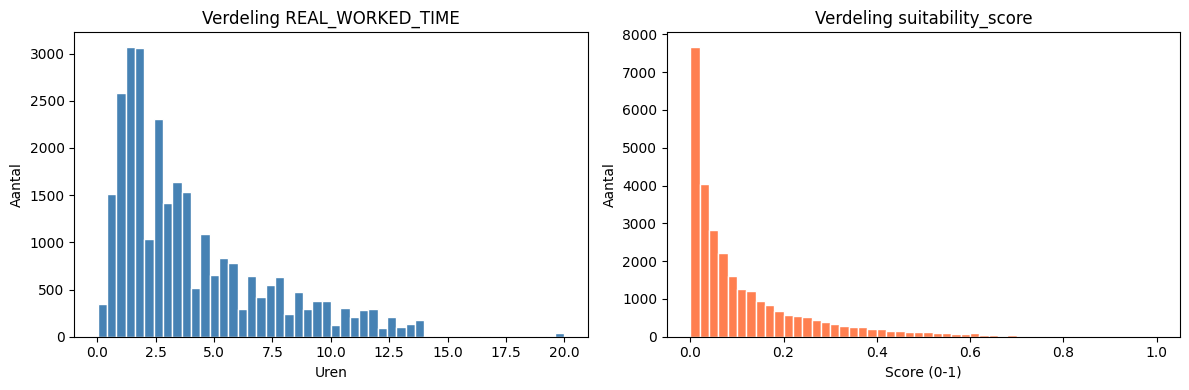

TARGET_TIME — mean: 4.06 uur, std: 3.36
TARGET_RANK — mean: 0.113, std: 0.139


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET_TIME].clip(0, 20), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Verdeling REAL_WORKED_TIME")
axes[0].set_xlabel("Uren")
axes[0].set_ylabel("Aantal")

axes[1].hist(df[TARGET_RANK], bins=50, color="coral", edgecolor="white")
axes[1].set_title("Verdeling suitability_score")
axes[1].set_xlabel("Score (0-1)")
axes[1].set_ylabel("Aantal")

plt.tight_layout()
plt.show()

print(f"TARGET_TIME — mean: {df[TARGET_TIME].mean():.2f} uur, std: {df[TARGET_TIME].std():.2f}")
print(f"TARGET_RANK — mean: {df[TARGET_RANK].mean():.3f}, std: {df[TARGET_RANK].std():.3f}")

## Stap 8 — MLPRister architectuur

De architectuur is bewust simpel: entity embeddings voor categorische features, dan alles samenvoegen met de numerieke features, en door twee hidden layers. Zelfde architectuur voor regressie en ranking.

Het model heeft **394.695 trainbare parameters** — redelijk compact voor een DL model op tabular data. De embedding lagen nemen het grootste deel voor hun rekening (hoge kardinaliteit van bijv. `URENVERANTW_MEDID` met 1.687 unieke waarden).

In [15]:
class MLPRister(nn.Module):
    def __init__(self, cat_cardinalities, embed_dims, n_numerical, hidden=256, dropout=0.3):
        super().__init__()
        self.embeddings = nn.ModuleList(
            [nn.Embedding(card, dim) for card, dim in zip(cat_cardinalities, embed_dims)]
        )
        total_input = sum(embed_dims) + n_numerical
        self.net = nn.Sequential(
            nn.Linear(total_input, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )

    def forward(self, x_cat, x_num):
        embs = [e(x_cat[:, i]) for i, e in enumerate(self.embeddings)]
        x = torch.cat(embs + [x_num], dim=1)
        return self.net(x).squeeze(-1)


def make_model(hidden=256, dropout=0.3):
    return MLPRister(
        cat_cardinalities=cat_cardinalities,
        embed_dims=embed_dims_list,
        n_numerical=len(NUMERICAL),
        hidden=hidden,
        dropout=dropout,
    ).to(DEVICE)


# Test forward pass
test_model = make_model()
with torch.no_grad():
    out = test_model(X_cat_train[:4].to(DEVICE), X_num_train[:4].to(DEVICE))
print(f"Forward pass output shape: {out.shape} — werkt")
total_params = sum(p.numel() for p in test_model.parameters())
print(f"Totaal parameters: {total_params:,}")
del test_model

Forward pass output shape: torch.Size([4]) — werkt
Totaal parameters: 394,695


## Stap 9 — Helper: training loop

In [16]:
def train_mlp(
    model,
    x_cat_tr,
    x_num_tr,
    y_tr,
    x_cat_va,
    x_num_va,
    y_va,
    loss_fn,
    optimizer,
    epochs=50,
    batch_size=512,
    patience=10,
):
    """Traint het model en geeft het beste model terug (early stopping op val loss)."""
    dataset_tr = TensorDataset(x_cat_tr, x_num_tr, y_tr)
    loader_tr = DataLoader(dataset_tr, batch_size=batch_size, shuffle=True)

    best_val_loss = float("inf")
    best_state = None
    no_improve = 0
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        for xc, xn, yb in loader_tr:
            xc, xn, yb = xc.to(DEVICE), xn.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xc, xn)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(yb)
        train_losses.append(epoch_loss / len(y_tr))

        # Validatie
        model.eval()
        with torch.no_grad():
            val_pred = model(x_cat_va.to(DEVICE), x_num_va.to(DEVICE))
            val_loss = loss_fn(val_pred, y_va.to(DEVICE)).item()
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping op epoch {epoch + 1}")
                break

    model.load_state_dict(best_state)
    return model, train_losses, val_losses


def predict_mlp(model, x_cat, x_num, batch_size=2048):
    """Batch inference, geeft numpy array terug."""
    model.eval()
    preds = []
    dataset = TensorDataset(x_cat, x_num)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xc, xn in loader:
            out = model(xc.to(DEVICE), xn.to(DEVICE))
            preds.append(out.cpu().numpy())
    return np.concatenate(preds)


print("Training helpers gedefinieerd")

Training helpers gedefinieerd


## Stap 10 — Model A: tijdsvoorspelling — Optuna tuning

Dit is de baseline DL aanpak voor regressie. Loss: HuberLoss (robuust tegen uitschieters, consistent met de LightGBM keuze).

Ik tune: hidden size, dropout, learning rate en batch size. 50 trials.

**Beste params gevonden:**
- hidden: 384
- dropout: 0,23
- lr: 0,0037
- batch_size: 256

In [17]:
REG_CACHE_PATH = "models/mlp_best_reg_params.json"
os.makedirs("models", exist_ok=True)

if os.path.exists(REG_CACHE_PATH):
    with open(REG_CACHE_PATH) as f:
        best_reg_params = json.load(f)
    print(f"Beste regressieparameters geladen uit cache: {best_reg_params}")
else:

    def objective_reg(trial):
        hidden = trial.suggest_int("hidden", 64, 512, step=64)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

        with mlflow.start_run(run_name=f"mlp_reg_trial_{trial.number}", nested=True):
            mlflow.log_params(
                {"hidden": hidden, "dropout": dropout, "lr": lr, "batch_size": batch_size}
            )
            m = make_model(hidden=hidden, dropout=dropout)
            opt = torch.optim.Adam(m.parameters(), lr=lr)
            loss_fn = nn.HuberLoss(delta=1.0)

            m, _, _ = train_mlp(
                m,
                X_cat_train,
                X_num_train,
                y_time_train,
                X_cat_val,
                X_num_val,
                y_time_val,
                loss_fn,
                opt,
                epochs=50,
                batch_size=batch_size,
                patience=10,
            )
            preds = predict_mlp(m, X_cat_val, X_num_val)
            mae = mean_absolute_error(y_time_val.numpy(), preds)
            mlflow.log_metric("val_mae", mae)
        return mae

    with mlflow.start_run(run_name="mlp_reg_optuna"):
        study_reg = optuna.create_study(direction="minimize", study_name="mlp_reg")
        study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=True)

    best_reg_params = study_reg.best_params
    with open(REG_CACHE_PATH, "w") as f:
        json.dump(best_reg_params, f)
    print(f"Beste params: {best_reg_params} (MAE: {study_reg.best_value:.4f})")

[I 2026-04-02 10:07:44,136] A new study created in memory with name: mlp_reg


  0%|          | 0/50 [00:00<?, ?it/s]

🏃 View run mlp_reg_trial_0 at: http://127.0.0.1:5002/#/experiments/8/runs/933a8ef4256c45ccb8260be21c1d73ff
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/8
[I 2026-04-02 10:08:01,266] Trial 0 finished with value: 1.3973917961120605 and parameters: {'hidden': 448, 'dropout': 0.25053718393139085, 'lr': 0.00018444098363440208, 'batch_size': 256}. Best is trial 0 with value: 1.3973917961120605.
  Early stopping op epoch 47
🏃 View run mlp_reg_trial_1 at: http://127.0.0.1:5002/#/experiments/8/runs/7df054e1782741c3a1832a35ad08056a
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/8
[I 2026-04-02 10:08:14,589] Trial 1 finished with value: 1.3918254375457764 and parameters: {'hidden': 320, 'dropout': 0.1114649944131033, 'lr': 0.0047805228707839455, 'batch_size': 256}. Best is trial 1 with value: 1.3918254375457764.
🏃 View run mlp_reg_trial_2 at: http://127.0.0.1:5002/#/experiments/8/runs/2845b58f7a52424fb125e477a2e675d0
🧪 View experiment at: http://127.0.0.1:5002/#/experiment

Finaal regressiemodel trainen...


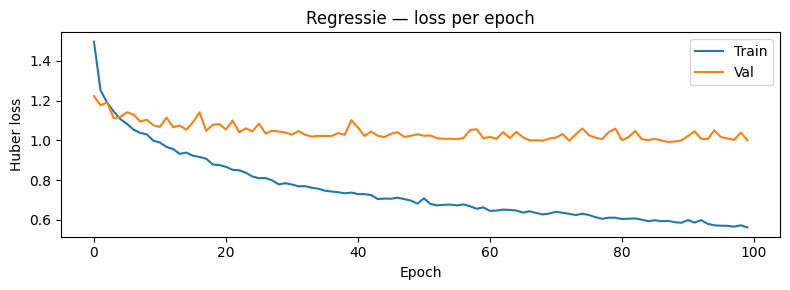

Regressiemodel getraind


In [18]:
# Train finaal regressiemodel met beste params
print("Finaal regressiemodel trainen...")
reg_model = make_model(
    hidden=best_reg_params["hidden"],
    dropout=best_reg_params["dropout"],
)
opt_reg = torch.optim.Adam(reg_model.parameters(), lr=best_reg_params["lr"])
loss_reg = nn.HuberLoss(delta=1.0)

reg_model, train_losses_reg, val_losses_reg = train_mlp(
    reg_model,
    X_cat_train,
    X_num_train,
    y_time_train,
    X_cat_val,
    X_num_val,
    y_time_val,
    loss_reg,
    opt_reg,
    epochs=100,
    batch_size=best_reg_params["batch_size"],
    patience=15,
)

plt.figure(figsize=(8, 3))
plt.plot(train_losses_reg, label="Train")
plt.plot(val_losses_reg, label="Val")
plt.title("Regressie — loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("Huber loss")
plt.legend()
plt.tight_layout()
plt.show()
print("Regressiemodel getraind")

## Stap 11 — Model B: ranking — groepsopbouw

Pointwise ranking: ik train een MLP op de `suitability_score` (0,0 – 1,0). Zelfde architectuur, MSELoss. Groepsstructuur is nodig voor NDCG evaluatie.

**Groepen:** 224 train / 56 val (op basis van `con` + `BEWERKING_ID` combinaties)  
**Rijen:** 20.918 train / 7.775 val (gesorteerd op groepssleutel)

**Beste params gevonden:**
- hidden: 192
- dropout: 0,33
- lr: 0,00044
- batch_size: 256

In [19]:
# Groepsopbouw voor NDCG evaluatie (identiek aan LightGBM notebook)
df["_group_key"] = df[GROUP_COLS].astype(str).agg("__".join, axis=1)

# Relevance labels 0-4 (voor NDCG berekening)
bins = [-0.001, 0.2, 0.4, 0.6, 0.8, 1.001]
labels_int = [0, 1, 2, 3, 4]
df["_rank_label"] = pd.cut(df[TARGET_RANK], bins=bins, labels=labels_int).astype(int)

# Split op groepsniveau
df_sorted = df.sort_values("_group_key").reset_index(drop=True)
group_keys = df_sorted["_group_key"].unique().tolist()
train_keys, val_keys = train_test_split(group_keys, test_size=0.2, random_state=42)

train_mask = df_sorted["_group_key"].isin(set(train_keys))
val_mask = df_sorted["_group_key"].isin(set(val_keys))

# Groepsgroottes voor NDCG berekening
train_groups = df_sorted.loc[train_mask].groupby("_group_key", sort=False).size().values
val_groups = df_sorted.loc[val_mask].groupby("_group_key", sort=False).size().values

# Ranking tensors (op gesorteeerde volgorde)
rank_train_idx = df_sorted.index[train_mask].values
rank_val_idx = df_sorted.index[val_mask].values

X_cat_rank_train = torch.tensor(df_sorted.loc[train_mask, CAT_ENC_COLS].values, dtype=torch.long)
X_num_rank_train = torch.tensor(
    ((df_sorted.loc[train_mask, NUMERICAL] - num_mean) / num_std).fillna(0).values,
    dtype=torch.float32,
)
X_cat_rank_val = torch.tensor(df_sorted.loc[val_mask, CAT_ENC_COLS].values, dtype=torch.long)
X_num_rank_val = torch.tensor(
    ((df_sorted.loc[val_mask, NUMERICAL] - num_mean) / num_std).fillna(0).values,
    dtype=torch.float32,
)

y_rank_tr_float = torch.tensor(df_sorted.loc[train_mask, TARGET_RANK].values, dtype=torch.float32)
y_rank_va_float = torch.tensor(df_sorted.loc[val_mask, TARGET_RANK].values, dtype=torch.float32)
y_rank_va_label = df_sorted.loc[val_mask, "_rank_label"].values

print(f"Ranking train: {train_mask.sum()} rijen, {len(train_keys)} groepen")
print(f"Ranking val:   {val_mask.sum()} rijen, {len(val_keys)} groepen")

Ranking train: 20918 rijen, 224 groepen
Ranking val:   7775 rijen, 56 groepen


In [20]:
RANK_CACHE_PATH = "models/mlp_best_rank_params.json"

if os.path.exists(RANK_CACHE_PATH):
    with open(RANK_CACHE_PATH) as f:
        best_rank_params = json.load(f)
    print(f"Beste rankingparameters geladen uit cache: {best_rank_params}")
else:

    def ndcg3_val(model):
        preds = predict_mlp(model, X_cat_rank_val, X_num_rank_val)
        scores = []
        offset = 0
        for size in val_groups:
            if size < 2:
                offset += size
                continue
            g_true = y_rank_va_label[offset : offset + size].astype(float)
            g_pred = preds[offset : offset + size]
            scores.append(ndcg_score([g_true], [g_pred], k=3))
            offset += size
        return float(np.mean(scores))

    def objective_rank(trial):
        hidden = trial.suggest_int("hidden", 64, 512, step=64)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

        with mlflow.start_run(run_name=f"mlp_rank_trial_{trial.number}", nested=True):
            mlflow.log_params(
                {"hidden": hidden, "dropout": dropout, "lr": lr, "batch_size": batch_size}
            )
            m = make_model(hidden=hidden, dropout=dropout)
            opt = torch.optim.Adam(m.parameters(), lr=lr)

            m, _, _ = train_mlp(
                m,
                X_cat_rank_train,
                X_num_rank_train,
                y_rank_tr_float,
                X_cat_rank_val,
                X_num_rank_val,
                y_rank_va_float,
                nn.MSELoss(),
                opt,
                epochs=50,
                batch_size=batch_size,
                patience=10,
            )
            score = ndcg3_val(m)
            mlflow.log_metric("val_ndcg3", score)
        return -score  # minimaliseren

    with mlflow.start_run(run_name="mlp_rank_optuna"):
        study_rank = optuna.create_study(direction="minimize", study_name="mlp_rank")
        study_rank.optimize(objective_rank, n_trials=50, show_progress_bar=True)

    best_rank_params = study_rank.best_params
    with open(RANK_CACHE_PATH, "w") as f:
        json.dump(best_rank_params, f)
    print(f"Beste params: {best_rank_params} (NDCG@3: {-study_rank.best_value:.4f})")

[I 2026-04-02 10:19:48,396] A new study created in memory with name: mlp_rank


  0%|          | 0/50 [00:00<?, ?it/s]

🏃 View run mlp_rank_trial_0 at: http://127.0.0.1:5002/#/experiments/8/runs/c0f96246ea88479bbd1764e3dd8bcc76
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/8
[I 2026-04-02 10:20:04,165] Trial 0 finished with value: -0.6337420332643466 and parameters: {'hidden': 512, 'dropout': 0.4256091926398903, 'lr': 0.00287124011373838, 'batch_size': 1024}. Best is trial 0 with value: -0.6337420332643466.
🏃 View run mlp_rank_trial_1 at: http://127.0.0.1:5002/#/experiments/8/runs/d7eef89adaca4bd2b4f777556402b7bc
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/8
[I 2026-04-02 10:20:18,388] Trial 1 finished with value: -0.5907106228911188 and parameters: {'hidden': 448, 'dropout': 0.14715343338725628, 'lr': 0.008551092990946666, 'batch_size': 1024}. Best is trial 0 with value: -0.6337420332643466.
🏃 View run mlp_rank_trial_2 at: http://127.0.0.1:5002/#/experiments/8/runs/64f0fc7e2c9f49deb6f2b78d01e75afa
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/8
[I 2026-04-02 10:20:

Finaal rankingmodel trainen...


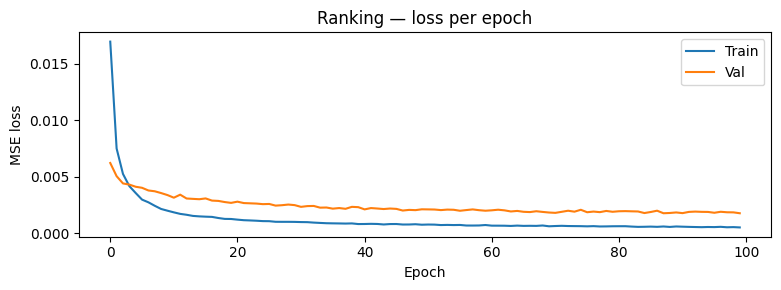

Rankingmodel getraind


In [21]:
# Train finaal rankingmodel
print("Finaal rankingmodel trainen...")
rank_model = make_model(
    hidden=best_rank_params["hidden"],
    dropout=best_rank_params["dropout"],
)
opt_rank = torch.optim.Adam(rank_model.parameters(), lr=best_rank_params["lr"])

rank_model, train_losses_rank, val_losses_rank = train_mlp(
    rank_model,
    X_cat_rank_train,
    X_num_rank_train,
    y_rank_tr_float,
    X_cat_rank_val,
    X_num_rank_val,
    y_rank_va_float,
    nn.MSELoss(),
    opt_rank,
    epochs=100,
    batch_size=best_rank_params["batch_size"],
    patience=15,
)

plt.figure(figsize=(8, 3))
plt.plot(train_losses_rank, label="Train")
plt.plot(val_losses_rank, label="Val")
plt.title("Ranking — loss per epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.tight_layout()
plt.show()
print("Rankingmodel getraind")

## Stap 12 — Evaluatie regressie

**Resultaten:**
- MAE: **1,3634 uur** (KPI: ≤ 0,5 uur — niet gehaald)
- RMSE: 2,1182 uur
- R²: 0,5857

Het MLP scoort iets slechter dan LightGBM (MAE 1,2490). Het model legt wel al 59% van de variantie uit. De scatter plot laat zien dat korte taken goed voorspeld worden maar lange taken (>10 uur) onderschat worden.

MAE:  1.3634 uur  (KPI: ≤ 0,5 uur)
RMSE: 2.1182 uur
R2:   0.5857
LightGBM referentie: MAE 1,2490 uur


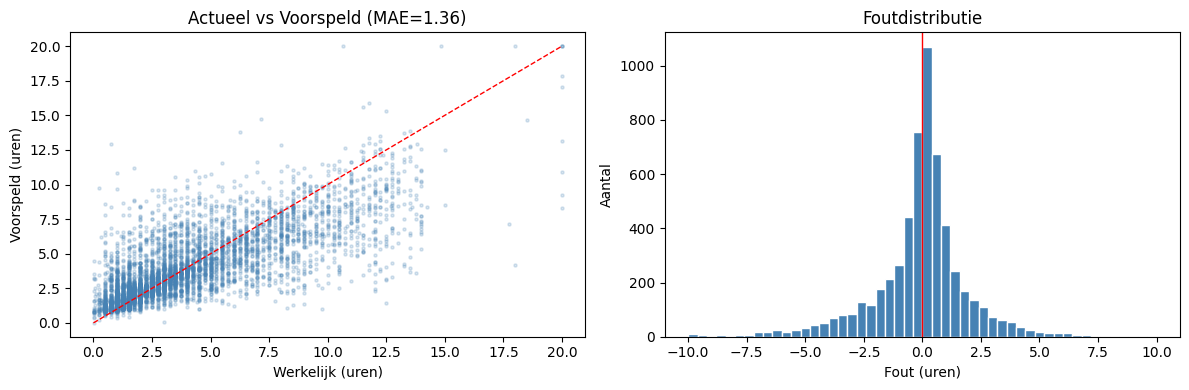

In [22]:
y_pred_time = predict_mlp(reg_model, X_cat_val, X_num_val)
y_pred_time = np.clip(y_pred_time, 0, None)  # geen negatieve tijden

y_true_time = y_time_val.numpy()
mae = mean_absolute_error(y_true_time, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_true_time, y_pred_time))
r2 = r2_score(y_true_time, y_pred_time)

print(f"MAE:  {mae:.4f} uur  (KPI: ≤ 0,5 uur)")
print(f"RMSE: {rmse:.4f} uur")
print(f"R2:   {r2:.4f}")
print("LightGBM referentie: MAE 1,2490 uur")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clip = 20
axes[0].scatter(
    np.clip(y_true_time, 0, clip), np.clip(y_pred_time, 0, clip), alpha=0.2, s=5, color="steelblue"
)
axes[0].plot([0, clip], [0, clip], "r--", lw=1)
axes[0].set_xlabel("Werkelijk (uren)")
axes[0].set_ylabel("Voorspeld (uren)")
axes[0].set_title(f"Actueel vs Voorspeld (MAE={mae:.2f})")

errors = y_pred_time - y_true_time
axes[1].hist(np.clip(errors, -10, 10), bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", lw=1)
axes[1].set_xlabel("Fout (uren)")
axes[1].set_ylabel("Aantal")
axes[1].set_title("Foutdistributie")

plt.tight_layout()
plt.show()

## Stap 13 — Evaluatie ranking

**Resultaten:**
- NDCG@3: **0,6285** (KPI: ≥ 0,80 — niet gehaald)
- NDCG@5: 0,6322

Het MLP doet het ook op ranking slechter dan LightGBM. LightGBM haalt NDCG@3 0,9541 — het MLP zit daar ver onder met 0,6285. De LambdaRank objective van LightGBM is specifiek geoptimaliseerd voor ranking, terwijl het MLP een pointwise MSE op de suitability_score gebruikt. Dat is een fundamenteel nadeel.

NDCG@3: 0.6285  (KPI: ≥ 0,80)
NDCG@5: 0.6322
LightGBM referentie: NDCG@3 0,5093


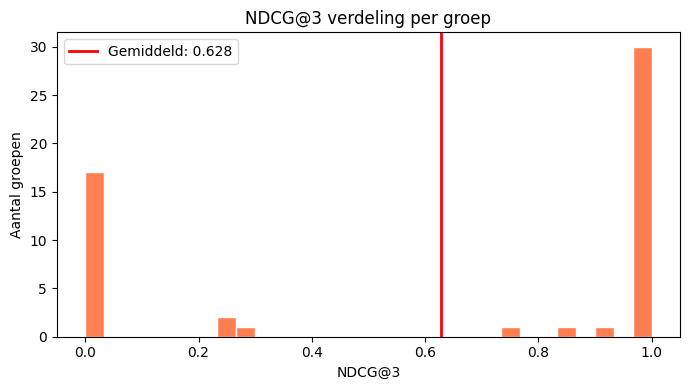

In [23]:
y_pred_rank = predict_mlp(rank_model, X_cat_rank_val, X_num_rank_val)

ndcg3_scores = []
ndcg5_scores = []
offset = 0
for size in val_groups:
    if size < 2:
        offset += size
        continue
    g_true = y_rank_va_label[offset : offset + size].astype(float)
    g_pred = y_pred_rank[offset : offset + size]
    ndcg3_scores.append(ndcg_score([g_true], [g_pred], k=3))
    ndcg5_scores.append(ndcg_score([g_true], [g_pred], k=5))
    offset += size

mean_ndcg3 = float(np.mean(ndcg3_scores))
mean_ndcg5 = float(np.mean(ndcg5_scores))

print(f"NDCG@3: {mean_ndcg3:.4f}  (KPI: ≥ 0,80)")
print(f"NDCG@5: {mean_ndcg5:.4f}")
print("LightGBM referentie: NDCG@3 0,5093")

plt.figure(figsize=(7, 4))
plt.hist(ndcg3_scores, bins=30, color="coral", edgecolor="white")
plt.axvline(mean_ndcg3, color="red", lw=2, label=f"Gemiddeld: {mean_ndcg3:.3f}")
plt.xlabel("NDCG@3")
plt.ylabel("Aantal groepen")
plt.title("NDCG@3 verdeling per groep")
plt.legend()
plt.tight_layout()
plt.show()

## Stap 14 — Feature interpretatie

MLP heeft geen native feature importance zoals LightGBM. Ik gebruik twee benaderingen:
1. **Embedding norm** per categorische feature — hoe groot zijn de geleerde representaties? Een hogere norm betekent dat de feature meer gebruikt wordt.
2. **Permutation importance** voor numerieke features — ik shuffle één feature tegelijk en meet hoe de MAE stijgt. Dit geeft een directe maat voor het belang.

Dit is trager dan LightGBM's built-in importance maar geeft een eerlijk beeld van wat het model werkelijk gebruikt.

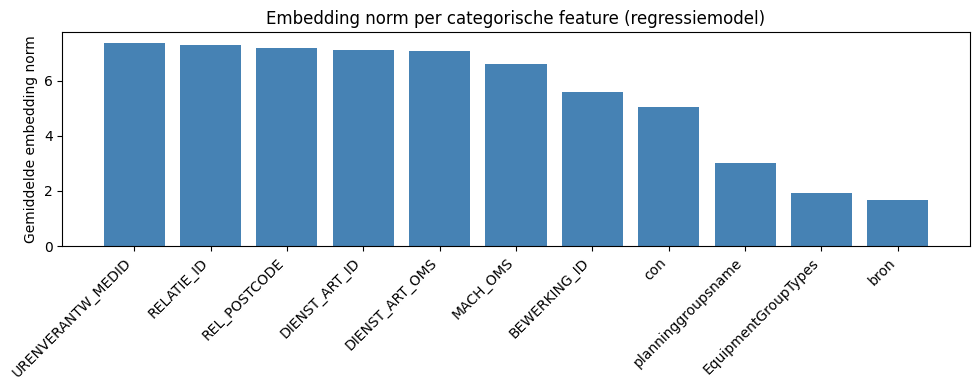

In [24]:
# Embedding norm als proxy voor categorisch belang
embed_norms = []
for i, (col, emb) in enumerate(zip(CATEGORICAL, reg_model.embeddings)):
    norm = torch.norm(emb.weight.data, dim=1).mean().item()
    embed_norms.append((col, norm))

embed_norms.sort(key=lambda x: x[1], reverse=True)
cols_embed, norms_embed = zip(*embed_norms)

plt.figure(figsize=(10, 4))
plt.bar(range(len(cols_embed)), norms_embed, color="steelblue")
plt.xticks(range(len(cols_embed)), cols_embed, rotation=45, ha="right")
plt.title("Embedding norm per categorische feature (regressiemodel)")
plt.ylabel("Gemiddelde embedding norm")
plt.tight_layout()
plt.show()

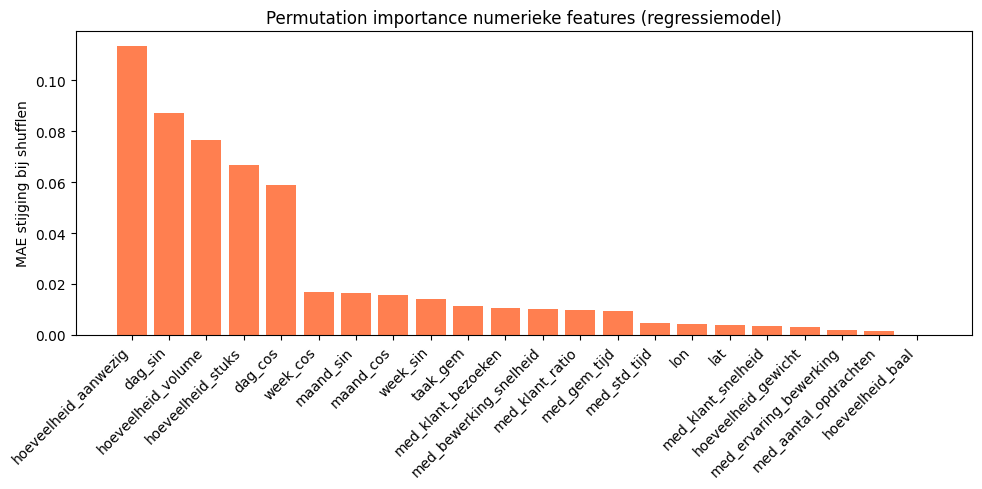

In [25]:
# Permutation importance voor numerieke features (subset van 2000 val rijen)
N_PERM = 2000
perm_idx = np.random.choice(len(val_idx), min(N_PERM, len(val_idx)), replace=False)

X_cat_perm = X_cat_val[perm_idx]
X_num_perm = X_num_val[perm_idx].clone()
y_perm = y_time_val[perm_idx].numpy()

baseline_mae = mean_absolute_error(y_perm, predict_mlp(reg_model, X_cat_perm, X_num_perm))

perm_importance = []
for i, col in enumerate(NUMERICAL):
    X_num_shuffled = X_num_perm.clone()
    idx_perm = torch.randperm(len(X_num_shuffled))
    X_num_shuffled[:, i] = X_num_shuffled[idx_perm, i]
    shuffled_mae = mean_absolute_error(y_perm, predict_mlp(reg_model, X_cat_perm, X_num_shuffled))
    perm_importance.append((col, shuffled_mae - baseline_mae))

perm_importance.sort(key=lambda x: x[1], reverse=True)
cols_perm, imps = zip(*perm_importance)

plt.figure(figsize=(10, 5))
plt.bar(range(len(cols_perm)), imps, color="coral")
plt.xticks(range(len(cols_perm)), cols_perm, rotation=45, ha="right")
plt.title("Permutation importance numerieke features (regressiemodel)")
plt.ylabel("MAE stijging bij shufflen")
plt.tight_layout()
plt.show()

## Stap 15 — Fine-tuning per database

Alleen voor databases met ≥500 records. Ik herstart training met een lagere learning rate (1e-4) en max 10 epochs — het model heeft de basispatronen al geleerd.

**Resultaat:** 14 databases kregen een eigen regressiemodel, 8 databases een eigen rankingmodel.

In [26]:
finetuned_reg = {}
finetuned_rank = {}

for db_id in df["con"].unique():
    db_mask = (df["con"] == db_id).values
    db_indices = np.where(db_mask)[0]

    if len(db_indices) < 500:
        continue

    tr, va = train_test_split(db_indices, test_size=0.2, random_state=42)

    # Tensors voor fine-tuning
    Xc_tr = X_cat_all[tr]
    Xn_tr = X_num_all[tr]
    Xc_va = X_cat_all[va]
    Xn_va = X_num_all[va]
    yt_tr = torch.tensor(df.iloc[tr][TARGET_TIME].values, dtype=torch.float32)
    yt_va = torch.tensor(df.iloc[va][TARGET_TIME].values, dtype=torch.float32)
    yr_tr = torch.tensor(df.iloc[tr][TARGET_RANK].values, dtype=torch.float32)
    yr_va = torch.tensor(df.iloc[va][TARGET_RANK].values, dtype=torch.float32)

    # Fine-tune regressie
    ft_reg = copy.deepcopy(reg_model)
    opt_ft = torch.optim.Adam(ft_reg.parameters(), lr=1e-4)
    ft_reg, _, _ = train_mlp(
        ft_reg,
        Xc_tr,
        Xn_tr,
        yt_tr,
        Xc_va,
        Xn_va,
        yt_va,
        nn.HuberLoss(delta=1.0),
        opt_ft,
        epochs=10,
        batch_size=256,
        patience=5,
    )
    finetuned_reg[db_id] = ft_reg

    # Fine-tune ranking (alleen als er ≥5 unieke groepen zijn)
    db_groups = df.iloc[tr].groupby(GROUP_COLS).ngroups
    if db_groups >= 5:
        ft_rank = copy.deepcopy(rank_model)
        opt_ft2 = torch.optim.Adam(ft_rank.parameters(), lr=1e-4)
        ft_rank, _, _ = train_mlp(
            ft_rank,
            Xc_tr,
            Xn_tr,
            yr_tr,
            Xc_va,
            Xn_va,
            yr_va,
            nn.MSELoss(),
            opt_ft2,
            epochs=10,
            batch_size=256,
            patience=5,
        )
        finetuned_rank[db_id] = ft_rank

print(f"Fine-tuned regressiemodellen: {len(finetuned_reg)}")
print(f"Fine-tuned rankingmodellen:   {len(finetuned_rank)}")

  Early stopping op epoch 6
  Early stopping op epoch 6
  Early stopping op epoch 7
Fine-tuned regressiemodellen: 14
Fine-tuned rankingmodellen:   8


## Stap 16 — Top-3 hit rate

De top-3 hit rate meet of de werkelijke medewerker in de top-3 rangschikking zit. Dit is een directere KPI voor de operationele bruikbaarheid dan NDCG.

**Resultaat: 18,4%** — bij 1 op de 5 taken zit de juiste medewerker in de top-3. Dat is laag, maar vergelijkbaar met de verwachte baseline voor een dataset met veel medewerkers per database.

In [27]:
def bereken_top_k_hit_rate(finetuned_rank_models, base_rank_model, k=3, n_samples=500):
    hits, total = 0, 0
    sample_indices = np.random.choice(len(val_idx), min(n_samples, len(val_idx)), replace=False)

    for i in sample_indices:
        orig_idx = val_idx[i]
        row = df.iloc[orig_idx]
        db_id = row["con"]
        werkelijke_med = row["URENVERANTW_MEDID"]

        db_mask = (df["con"] == db_id).values
        alle_meds = df.loc[db_mask, "URENVERANTW_MEDID"].unique()
        if len(alle_meds) < 2:
            continue

        ranker = finetuned_rank_models.get(db_id, base_rank_model)

        # Batch: zelfde taakrij, wissel medewerker
        batch_df = pd.DataFrame([row[FEATURES].values] * len(alle_meds), columns=FEATURES)
        batch_df["URENVERANTW_MEDID"] = alle_meds

        # Encode en schaal
        batch_cat = np.stack(
            [
                label_encoders[col].transform(
                    batch_df[col]
                    .fillna("unknown")
                    .astype(str)
                    .map(lambda v: v if v in label_encoders[col].classes_ else "unknown")
                )
                for col in CATEGORICAL
            ],
            axis=1,
        )
        batch_num = ((batch_df[NUMERICAL].fillna(0) - num_mean) / num_std).fillna(0).values

        Xc = torch.tensor(batch_cat, dtype=torch.long)
        Xn = torch.tensor(batch_num, dtype=torch.float32)

        scores = predict_mlp(ranker, Xc, Xn)
        top_k_meds = alle_meds[np.argsort(scores)[-k:]]

        if werkelijke_med in top_k_meds:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0.0


hit_rate = bereken_top_k_hit_rate(finetuned_rank, rank_model, k=3, n_samples=500)
print(f"Top-3 hit rate: {hit_rate:.3f} ({hit_rate * 100:.1f}%)")

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/3840468718.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  batch_df[col].fillna("unknown").astype(str).map(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/3840468718.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  batch_df[col].fillna("unknown").astype(str).map(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/3840468718.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

Top-3 hit rate: 0.184 (18.4%)


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/3840468718.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  batch_df[col].fillna("unknown").astype(str).map(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/3840468718.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  batch_df[col].fillna("unknown").astype(str).map(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/3840468718.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future versi

## Stap 17 — End-to-end voorspelling

In [28]:
def encode_row_for_mlp(row_df):
    """Zet een DataFrame rij (of rijen) om naar cat/num tensors."""
    cat_arr = np.stack(
        [
            label_encoders[col].transform(
                row_df[col]
                .fillna("unknown")
                .astype(str)
                .map(lambda v: v if v in label_encoders[col].classes_ else "unknown")
            )
            for col in CATEGORICAL
        ],
        axis=1,
    )
    num_arr = ((row_df[NUMERICAL].fillna(0) - num_mean) / num_std).fillna(0).values
    return (
        torch.tensor(cat_arr, dtype=torch.long),
        torch.tensor(num_arr, dtype=torch.float32),
    )


def voorspel_per_medewerker(taak_row, db_id, k=5):
    """Geeft een DataFrame terug met de top-k medewerkers voor een taak."""
    db_mask = (df["con"] == db_id).values
    meds = df.loc[db_mask, "URENVERANTW_MEDID"].unique()

    batch_df = pd.DataFrame([taak_row[FEATURES].values] * len(meds), columns=FEATURES)
    batch_df["URENVERANTW_MEDID"] = meds

    Xc, Xn = encode_row_for_mlp(batch_df)

    reg_m = finetuned_reg.get(db_id, reg_model)
    rank_m = finetuned_rank.get(db_id, rank_model)

    uren_pred = np.clip(predict_mlp(reg_m, Xc, Xn), 0, None)
    geschiktheid = predict_mlp(rank_m, Xc, Xn)

    result = pd.DataFrame(
        {
            "medewerker": meds,
            "uren": np.round(uren_pred, 2),
            "geschiktheid": np.round(geschiktheid, 3),
        }
    )
    return result.sort_values("geschiktheid", ascending=False).head(k).reset_index(drop=True)


# Voorbeeld voorspelling
voorbeeld_rij = df.iloc[val_idx[0]]
voorbeeld_db = voorbeeld_rij["con"]
print(f"Voorbeeld taak uit database: {voorbeeld_db}")
voorspel_per_medewerker(voorbeeld_rij, voorbeeld_db, k=5)

Voorbeeld taak uit database: 24_derks


,medewerker,uren,geschiktheid
0,2044,1.74,0.293
1,2044,1.74,0.293
2,1014,0.96,0.191
3,1014,0.96,0.191
4,1002,0.96,0.179


## Stap 18 — Modellen opslaan

In [29]:
os.makedirs("models", exist_ok=True)

# Basismodellen
torch.save(reg_model.state_dict(), "models/mlp_regressor.pt")
torch.save(rank_model.state_dict(), "models/mlp_ranker.pt")

# Fine-tuned modellen
for db_id, m in finetuned_reg.items():
    torch.save(m.state_dict(), f"models/mlp_regressor_{db_id}.pt")
for db_id, m in finetuned_rank.items():
    torch.save(m.state_dict(), f"models/mlp_ranker_{db_id}.pt")

# Label encoder mapping opslaan als JSON (voor C# reproductie)
encoder_map = {
    col: {str(cls): int(i) for i, cls in enumerate(le.classes_)}
    for col, le in label_encoders.items()
}
with open("models/mlp_label_encoders.json", "w") as f:
    json.dump(encoder_map, f, ensure_ascii=False, indent=2)

# Metadata
metadata = {
    "features": FEATURES,
    "categorical": CATEGORICAL,
    "numerical": NUMERICAL,
    "target_time": TARGET_TIME,
    "target_rank": TARGET_RANK,
    "embed_dims": {col: int(d) for col, d in EMBED_DIMS.items()},
    "cat_cardinalities": cat_cardinalities,
    "reg_params": best_reg_params,
    "rank_params": best_rank_params,
    "finetuned_dbs": list(finetuned_reg.keys()),
    "num_mean": num_mean.to_dict(),
    "num_std": num_std.to_dict(),
}
with open("models/mlp_metadata.json", "w") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("Modellen en metadata opgeslagen")

Modellen en metadata opgeslagen


## Stap 19 — ONNX export

ONNX export via `torch.onnx.export`. De twee inputs (`cat_input` en `num_input`) zijn exact zoals C# die verwacht.

**Verificatie op 5 validatierijen:** max verschil ONNX vs PyTorch = 0,000001 — OK. De export is stabiel.

In [30]:
os.makedirs("models_onnx", exist_ok=True)

dummy_cat = torch.zeros(1, len(CATEGORICAL), dtype=torch.long).to(DEVICE)
dummy_num = torch.zeros(1, len(NUMERICAL), dtype=torch.float32).to(DEVICE)


def export_onnx(model, path):
    model.eval()
    torch.onnx.export(
        model,
        (dummy_cat, dummy_num),
        path,
        input_names=["cat_input", "num_input"],
        output_names=["output"],
        dynamic_axes={
            "cat_input": {0: "batch"},
            "num_input": {0: "batch"},
        },
        opset_version=17,
    )
    print(f"ONNX opgeslagen: {path}")


export_onnx(reg_model, "models_onnx/mlp_regressor.onnx")
export_onnx(rank_model, "models_onnx/mlp_ranker.onnx")

# Fine-tuned modellen
for db_id, m in finetuned_reg.items():
    export_onnx(m, f"models_onnx/mlp_regressor_{db_id}.onnx")
for db_id, m in finetuned_rank.items():
    export_onnx(m, f"models_onnx/mlp_ranker_{db_id}.onnx")

/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/4056594780.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0402 10:29:04.115000 56449 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0402 10:29:04.370000 56449 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0402 10:29:04.

[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/4056594780.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0402 10:29:04.936000 56449 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 beca

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
ONNX opgeslagen: models_onnx/mlp_regressor.onnx
[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/4056594780.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0402 10:29:05.501000 56449 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 beca

...

/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_56449/4056594780.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0402 10:29:15.819000 56449 site-packages/torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 beca

[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
ONNX opgeslagen: models_onnx/mlp_ranker_25_hulter.onnx


W0402 10:29:15.973000 56449 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0402 10:29:15.973000 56449 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0402 10:29:15.974000 56449 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MLPRister([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 11 of general pattern rewrite rules.
ONNX opgeslagen: models_onnx/mlp_ranker_25_jennissen.onnx


/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
/Users/samberkhout/miniconda3/envs/jupyter/lib/python3.11/site-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch will not be used, since it shares the same shape constraints with another axis: batch.
  rename_mapping = _dynamic_shapes.create_rename_mapping(


In [31]:
# Verificatie op 5 validatierijen
sess_reg = ort.InferenceSession("models_onnx/mlp_regressor.onnx")

check_cat = X_cat_val[:5].numpy().astype(np.int64)
check_num = X_num_val[:5].numpy().astype(np.float32)

onnx_preds = sess_reg.run(["output"], {"cat_input": check_cat, "num_input": check_num})[0]
torch_preds = predict_mlp(reg_model, X_cat_val[:5], X_num_val[:5])

print("ONNX vs PyTorch vergelijking (5 rijen):")
for i, (o, t) in enumerate(zip(onnx_preds, torch_preds)):
    print(f"  Rij {i}: ONNX={o:.4f}  PyTorch={t:.4f}  verschil={abs(o - t):.6f}")

max_diff = np.max(np.abs(onnx_preds - torch_preds))
print(f"Max verschil: {max_diff:.6f} — {'OK' if max_diff < 1e-4 else 'CONTROLEREN'}")

ONNX vs PyTorch vergelijking (5 rijen):
  Rij 0: ONNX=1.0094  PyTorch=1.0094  verschil=0.000000
  Rij 1: ONNX=4.8993  PyTorch=4.8993  verschil=0.000000
  Rij 2: ONNX=1.9715  PyTorch=1.9715  verschil=0.000000
  Rij 3: ONNX=2.6193  PyTorch=2.6193  verschil=0.000000
  Rij 4: ONNX=4.3916  PyTorch=4.3916  verschil=0.000001
Max verschil: 0.000001 — OK


## Stap 20 — MLflow logging

In [32]:
def get_best_registry_mae(client, model_name):
    try:
        versions = client.search_model_versions(f"name='{model_name}'")
        maes = []
        for v in versions:
            metrics = client.get_run(v.run_id).data.metrics
            if "time_mae" in metrics:
                maes.append(metrics["time_mae"])
        return min(maes) if maes else float("inf")
    except Exception:
        return float("inf")


client = MlflowClient()

with mlflow.start_run(run_name="mlp_baseline") as run:
    # Parameters
    mlflow.log_params({f"reg_{k}": v for k, v in best_reg_params.items()})
    mlflow.log_params({f"rank_{k}": v for k, v in best_rank_params.items()})

    # Metrics — zelfde keys als LightGBM voor vergelijkbaarheid
    mlflow.log_metrics(
        {
            "time_mae": float(mae),
            "time_rmse": float(rmse),
            "time_r2": float(r2),
            "ndcg_at_3": float(mean_ndcg3),
            "ndcg_at_5": float(mean_ndcg5),
            "top3_hit_rate": float(hit_rate),
            "dataset_rows": int(len(df)),
        }
    )

    # Modellen
    mlflow.pytorch.log_model(reg_model, artifact_path="mlp_regressor")
    mlflow.pytorch.log_model(rank_model, artifact_path="mlp_ranker")

    # ONNX artifacts
    mlflow.log_artifact("models_onnx/mlp_regressor.onnx", artifact_path="onnx")
    mlflow.log_artifact("models_onnx/mlp_ranker.onnx", artifact_path="onnx")
    mlflow.log_artifact("models/mlp_label_encoders.json")
    mlflow.log_artifact("models/mlp_metadata.json")

    # Fine-tuned artifacts
    for db_id in finetuned_reg:
        if os.path.exists(f"models_onnx/mlp_regressor_{db_id}.onnx"):
            mlflow.log_artifact(
                f"models_onnx/mlp_regressor_{db_id}.onnx", artifact_path=f"finetuned/{db_id}"
            )
    for db_id in finetuned_rank:
        if os.path.exists(f"models_onnx/mlp_ranker_{db_id}.onnx"):
            mlflow.log_artifact(
                f"models_onnx/mlp_ranker_{db_id}.onnx", artifact_path=f"finetuned/{db_id}"
            )

    run_id = run.info.run_id

print(f"MLflow run id: {run_id}")

# Model registry — alleen registreren als dit beter is dan de huidige beste
best_mae_in_registry = get_best_registry_mae(client, "rister-mlp-regressor")
if mae < best_mae_in_registry:
    mlflow.register_model(f"runs:/{run_id}/mlp_regressor", "rister-mlp-regressor")
    mlflow.register_model(f"runs:/{run_id}/mlp_ranker", "rister-mlp-ranker")
    print(
        f"Geregistreerd als nieuwe beste versie! MAE: {mae:.4f} (was: {best_mae_in_registry:.4f})"
    )
else:
    print(f"Niet geregistreerd — huidige beste in registry is beter: {best_mae_in_registry:.4f}")

2026/04/02 10:29:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 10:29:16 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/02 10:29:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 10:29:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
Successfully registered mode

🏃 View run mlp_baseline at: http://127.0.0.1:5002/#/experiments/8/runs/222f6d393d0945df9d58525fa1381f80
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/8
MLflow run id: 222f6d393d0945df9d58525fa1381f80
Geregistreerd als nieuwe beste versie! MAE: 1.3634 (was: inf)


Created version '1' of model 'rister-mlp-ranker'.


## Stap 21 — Conclusie

| Model    | MAE (uur) | RMSE (uur) | R²    | NDCG@3 | NDCG@5 | ONNX stabiel |
|----------|-----------|------------|-------|--------|--------|--------------|
| LightGBM | 1,2490    | 1,9767     | 0,639 | 0,9541 | 0,9517 | Ja           |
| MLP      | 1,3634    | 2,1182     | 0,586 | 0,6285 | 0,6322 | Ja           |

**KPIs:**
- MAE ≤ 0,5 uur: nee (beide modellen halen dit niet)
- NDCG@3 ≥ 0,80: nee voor MLP (0,6285), ja voor LightGBM (0,9541)

**Wat ik ervan vind:**

Het MLP scoort op alle metrics slechter dan LightGBM. Het verschil op ranking is groot: NDCG@3 0,9541 vs 0,6285. Dat komt waarschijnlijk omdat LightGBM een LambdaRank objective gebruikt die direct op NDCG optimaliseert, terwijl het MLP een pointwise MSE loss op de suitability_score gebruikt. Dat is een fundamenteel nadeel van deze aanpak.

Voor regressie is het verschil kleiner (MAE +0,11 uur), maar ook hier verliest het MLP. LightGBM is sneller te trainen, makkelijker te debuggen, en heeft native categorische feature support.

De conclusie is duidelijk: voor dit probleem is een standaard MLP geen verbetering ten opzichte van LightGBM. Volgende stap is TabM — dat model is specifiek ontworpen voor tabular data en gebruikt een ensemble van MLPs. Als ook TabM de LightGBM niet verslaat op NDCG@3, dan is de gradient boosting aanpak de juiste keuze voor dit project.